In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# ==============================================================================
# 0. ライブラリインストール & 初期設定
# ==============================================================================
!pip install prophet xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.graphics.tsaplots import plot_acf
import random
import warnings
import os
import matplotlib.dates as mdates
# 警告制御
warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:.2f}'.format

# シード固定（再現性確保）
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything(42)

# 表4.1：予測精度の比較

## 前年度繰り返し

In [6]:
# ==============================================================================
# 1. データ読み込み & 前処理
# ==============================================================================
file_path = '/content/drive/MyDrive/Colab Notebooks/卒業研究/データ/価格、数量.csv'

data = pd.read_csv(file_path)

data_filtered = data[data['価格'] > 0].copy()
data_filtered['日付'] = pd.to_datetime(data_filtered['日付'])

df_master = data_filtered.rename(columns={'日付': 'ds', '価格': 'y'}).sort_values('ds').reset_index(drop=True)

full_date_range = pd.date_range(start=df_master['ds'].min(), end=df_master['ds'].max(), freq='D')
df_daily = pd.DataFrame({'ds': full_date_range})
df_daily = df_daily.merge(df_master[['ds', 'y']], on='ds', how='left')

df_daily['y_filled'] = df_daily['y'].interpolate(method='linear')

# 検索を高速化するために日付をインデックスにしておく
price_lookup = df_daily.set_index('ds')['y_filled']

# 検証設定
VALIDATION_CONFIGS = [
    {
        'label': '2022年度',
        'TEST_START':  '2022-08-01',
        'TEST_END':    '2023-07-31'
    },
    {
        'label': '2023年度',
        'TEST_START':  '2023-08-01',
        'TEST_END':    '2024-07-31'
    },
    {
        'label': '2024年度',
        'TEST_START':  '2024-08-01',
        'TEST_END':    '2025-07-31'
    }
]

# 結果格納用
results_metrics = []
all_predictions = pd.DataFrame()

# ==============================================================================
# 2. ループ処理 (年度ごとに予測・評価)
# ==============================================================================
for config in VALIDATION_CONFIGS:
    print(f"\n{'='*60}")
    print(f"■ 検証開始: {config['label']} (前年度踏襲モデル)")

    # --- テスト期間のデータ抽出 ---
    # 予測対象となる日のデータ（実績値と日付）を取得
    mask_test = (df_master['ds'] >= config['TEST_START']) & (df_master['ds'] <= config['TEST_END'])
    df_test = df_master[mask_test].copy().reset_index(drop=True)

    actual = df_test['y'].values
    dates = df_test['ds']

    # --- 予測（前年度の値を参照） ---
    # 予測したい日(dates)の「ちょうど1年前」の日付を計算
    dates_prev_year = dates - pd.DateOffset(years=1)

    # 1年前の日付を使って、用意しておいた price_lookup から価格を取得
    # mapを使うことで日付に対応する値を一括取得
    pred_values = dates_prev_year.map(price_lookup).values

    # もし1年前のデータが取得できない場合（データの開始直後など）はNaNになるので削除または埋める
    # 基本的にデータ期間が十分あればNaNは出ませんが、念のためfillna(0)などを入れても良い
    if np.isnan(pred_values).any():
        print("※一部の日付で1年前のデータが存在しませんでした。")
        # 今回は評価エラーを防ぐため、NaNがあればその行を除外して評価する処理を追加してもよいが
        # ここではそのまま進めます（データ期間が十分ならエラーになりません）

    final_pred = pred_values

    # --- 評価指標の計算 (MAE, RMSE, MAPE, RMSPE) ---
    # NaNが含まれているとエラーになるので念のため除去して計算
    valid_mask = ~np.isnan(final_pred)

    y_true = actual[valid_mask]
    y_pred = final_pred[valid_mask]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    # RMSPEの計算 (手動計算)
    # ((実測 - 予測) / 実測) の二乗平均の平方根
    rmspe = np.sqrt(np.mean(np.square((y_true - y_pred) / y_true))) * 100

    # 結果リストに追加
    results_metrics.append({
        'Year': config['label'],
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape,
        'RMSPE (%)': rmspe  # 追加
    })

    print(f"-> 結果: MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.2f}%, RMSPE={rmspe:.2f}%")

    # --- グラフ用データの蓄積 ---
    temp_df = pd.DataFrame({
        'ds': dates,
        'y': actual,
        'yhat': final_pred,
        'label': config['label']
    })
    all_predictions = pd.concat([all_predictions, temp_df], axis=0)

# ==============================================================================
# 3. 最終結果の集計と表示
# ==============================================================================
results_df = pd.DataFrame(results_metrics)

print(f"\n{'='*60}")
print("■ 3年間の検証結果まとめ (前年度踏襲モデル)")
print(f"{'='*60}")
print(results_df.to_string(index=False))

print(f"{'-'*60}")
# 平均値の計算
avg_mae = results_df['MAE'].mean()
avg_rmse = results_df['RMSE'].mean()
avg_mape = results_df['MAPE (%)'].mean()
avg_rmspe = results_df['RMSPE (%)'].mean() # 追加

print(f"★ 3期間平均 | MAE: {avg_mae:.2f} | RMSE: {avg_rmse:.2f} | MAPE: {avg_mape:.2f}% | RMSPE: {avg_rmspe:.2f}%")
print(f"{'='*60}")



■ 検証開始: 2022年度 (前年度踏襲モデル)
-> 結果: MAE=52.87, RMSE=62.26, MAPE=14.49%, RMSPE=16.94%

■ 検証開始: 2023年度 (前年度踏襲モデル)
-> 結果: MAE=96.64, RMSE=108.45, MAPE=21.14%, RMSPE=23.85%

■ 検証開始: 2024年度 (前年度踏襲モデル)
-> 結果: MAE=42.02, RMSE=54.49, MAPE=8.36%, RMSPE=10.48%

■ 3年間の検証結果まとめ (前年度踏襲モデル)
  Year   MAE   RMSE  MAPE (%)  RMSPE (%)
2022年度 52.87  62.26     14.49      16.94
2023年度 96.64 108.45     21.14      23.85
2024年度 42.02  54.49      8.36      10.48
------------------------------------------------------------
★ 3期間平均 | MAE: 63.84 | RMSE: 75.06 | MAPE: 14.66% | RMSPE: 17.09%


## Prophet単体

In [7]:
# ==============================================================================
# 1. データ読み込み & 前処理
# ==============================================================================
file_path = '/content/drive/MyDrive/Colab Notebooks/卒業研究/データ/価格、数量.csv'

# データ読み込み
data = pd.read_csv(file_path)

# 価格が0より大きいデータのみ抽出し、日付型に変換
data_filtered = data[data['価格'] > 0].copy()
data_filtered['日付'] = pd.to_datetime(data_filtered['日付'])

# Prophet用にリネームし、日付順にソート
df_master = data_filtered.rename(columns={'日付': 'ds', '価格': 'y'}).sort_values('ds').reset_index(drop=True)

# 検証設定 (Rolling Window)
VALIDATION_CONFIGS = [
    {
        'label': '2022年度',
        'TRAIN_START': '2014-08-01',
        'TRAIN_END':   '2022-07-31',
        'TEST_START':  '2022-08-01',
        'TEST_END':    '2023-07-31'
    },
    {
        'label': '2023年度',
        'TRAIN_START': '2015-08-01',
        'TRAIN_END':   '2023-07-31',
        'TEST_START':  '2023-08-01',
        'TEST_END':    '2024-07-31'
    },
    {
        'label': '2024年度',
        'TRAIN_START': '2016-08-01',
        'TRAIN_END':   '2024-07-31',
        'TEST_START':  '2024-08-01',
        'TEST_END':    '2025-07-31'
    }
]

# 結果格納用
results_metrics = []
all_predictions = pd.DataFrame()

# ==============================================================================
# 2. ループ処理 (年度ごとに学習・予測・評価)
# ==============================================================================
for config in VALIDATION_CONFIGS:
    print(f"\n{'='*60}")
    print(f"■ 検証開始: {config['label']}")
    print(f"   学習期間: {config['TRAIN_START']} ～ {config['TRAIN_END']}")

    # --- データの切り出し ---
    # 学習期間 + テスト期間の全データを抽出
    mask_period = (df_master['ds'] >= config['TRAIN_START']) & (df_master['ds'] <= config['TEST_END'])
    df_period = df_master[mask_period].copy().reset_index(drop=True)

    # 学習データ (Train)
    mask_train = (df_period['ds'] <= config['TRAIN_END'])
    df_train = df_period[mask_train].copy()

    # テストデータ (Test)
    mask_test = (df_period['ds'] >= config['TEST_START']) & (df_period['ds'] <= config['TEST_END'])

    # --- Prophet学習 (指定されたパラメータ) ---
    m = Prophet(
        growth='linear',
        n_changepoints=27,
        seasonality_mode='additive',
        yearly_seasonality=28,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_range=0.6756135296493135,
        seasonality_prior_scale=0.03063549790478998,
        changepoint_prior_scale=0.09679027817732291
    )

    m.fit(df_train[['ds', 'y']])

    # --- 予測 ---
    forecast = m.predict(df_period[['ds']])

    # テスト期間のデータを抽出
    final_pred = forecast.loc[mask_test, 'yhat'].values
    actual = df_period.loc[mask_test, 'y'].values
    dates = df_period.loc[mask_test, 'ds'].values

    # --- 評価指標の計算 (MAE, RMSE, MAPE, RMSPE) ---
    mae = mean_absolute_error(actual, final_pred)
    rmse = np.sqrt(mean_squared_error(actual, final_pred))
    mape = mean_absolute_percentage_error(actual, final_pred) * 100
    rmspe = np.sqrt(np.mean(np.square((actual - final_pred) / actual))) * 100

    # 結果リストに追加
    results_metrics.append({
        'Year': config['label'],
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape,
        'RMSPE (%)': rmspe  # 追加
    })

    print(f"-> 結果: MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.2f}%, RMSPE={rmspe:.2f}%")

    # --- グラフ用データの蓄積 ---
    temp_df = pd.DataFrame({
        'ds': dates,
        'y': actual,
        'yhat': final_pred,
        'label': config['label']
    })
    all_predictions = pd.concat([all_predictions, temp_df], axis=0)

# ==============================================================================
# 3. 最終結果の集計と表示
# ==============================================================================
results_df = pd.DataFrame(results_metrics)

print(f"\n{'='*60}")
print("■ 3年間の検証結果まとめ (多角評価)")
print(f"{'='*60}")
print(results_df.to_string(index=False))

print(f"{'-'*60}")
# 平均値の計算
avg_mae = results_df['MAE'].mean()
avg_rmse = results_df['RMSE'].mean()
avg_mape = results_df['MAPE (%)'].mean()
avg_rmspe = results_df['RMSPE (%)'].mean() # 追加

print(f"★ 3期間平均 | MAE: {avg_mae:.2f} | RMSE: {avg_rmse:.2f} | MAPE: {avg_mape:.2f}% | RMSPE: {avg_rmspe:.2f}%")
print(f"{'='*60}")


■ 検証開始: 2022年度
   学習期間: 2014-08-01 ～ 2022-07-31
-> 結果: MAE=28.93, RMSE=37.20, MAPE=7.13%, RMSPE=8.56%

■ 検証開始: 2023年度
   学習期間: 2015-08-01 ～ 2023-07-31
-> 結果: MAE=43.24, RMSE=52.06, MAPE=9.29%, RMSPE=11.45%

■ 検証開始: 2024年度
   学習期間: 2016-08-01 ～ 2024-07-31
-> 結果: MAE=41.88, RMSE=49.53, MAPE=8.86%, RMSPE=10.99%

■ 3年間の検証結果まとめ (多角評価)
  Year   MAE  RMSE  MAPE (%)  RMSPE (%)
2022年度 28.93 37.20      7.13       8.56
2023年度 43.24 52.06      9.29      11.45
2024年度 41.88 49.53      8.86      10.99
------------------------------------------------------------
★ 3期間平均 | MAE: 38.02 | RMSE: 46.27 | MAPE: 8.43% | RMSPE: 10.33%


## ハイブリッド（表4.2）

In [8]:
# ==============================================================================
# 1. データ読み込み & 前処理
# ==============================================================================
file_path = '/content/drive/MyDrive/Colab Notebooks/卒業研究/データ/価格、数量.csv'

data = pd.read_csv(file_path)
data['日付'] = pd.to_datetime(data['日付'])

# データ整理
data_filtered = data[data['価格'] > 0].copy()
df_master = data_filtered.rename(columns={'日付': 'ds', '価格': 'y'}).sort_values('ds').reset_index(drop=True)

# 検証設定
VALIDATION_CONFIGS = [
    {'label': '2022', 'TRAIN_START': '2014-08-01', 'TRAIN_END': '2022-07-31', 'TEST_START': '2022-08-01', 'TEST_END': '2023-07-31'},
    {'label': '2023', 'TRAIN_START': '2015-08-01', 'TRAIN_END': '2023-07-31', 'TEST_START': '2023-08-01', 'TEST_END': '2024-07-31'},
    {'label': '2024', 'TRAIN_START': '2016-08-01', 'TRAIN_END': '2024-07-31', 'TEST_START': '2024-08-01', 'TEST_END': '2025-07-31'}
]

# ==============================================================================
# 2. パラメータ設定
# ==============================================================================

Prophet_PARAMS = {
        'growth':'linear',
        'n_changepoints':27,
        'seasonality_mode':'additive',
        'yearly_seasonality':28,
        'weekly_seasonality':False,
        'daily_seasonality':False,
        'changepoint_range':0.6756135296493135,
        'seasonality_prior_scale':0.03063549790478998,
        'changepoint_prior_scale':0.09679027817732291,
}

XGB_PARAMS = {
    'objective': 'reg:absoluteerror',
    'eval_metric': 'mae',
    'booster': 'gbtree',
    'verbosity': 0,
    'seed': 42,
    'max_depth': 11,
    'learning_rate': 0.08008064281256923,
    'min_child_weight': 35,
    'alpha': 0.03240853469266926,
    'lambda': 0.03889764943325178,
    'colsample_bytree': 0.25694867854682896,
    'subsample': 0.7673783790335744,
}

GAP = 1  # 予測の余裕日数
LAGS = [1] # ラグ特徴量
WINDOWS = [5, 10, 21] # 移動平均のウィンドウサイズリスト

all_results_list = [] # 結果結合用

# ==============================================================================
# 3. ループ処理 (Prophet + XGBoost)
# ==============================================================================
for config in VALIDATION_CONFIGS:
    print(f"\n{'='*60}")
    print(f"■ 検証開始: {config['label']}")

    # 期間フィルタリング
    mask_period = (df_master['ds'] >= config['TRAIN_START']) & (df_master['ds'] <= config['TEST_END'])
    df_period = df_master[mask_period].copy().reset_index(drop=True)

    # --- 1. Prophet学習 (トレンド・季節性担当) ---
    print("1. Prophet学習中...")
    m = Prophet(**Prophet_PARAMS)

    train_df = df_period[df_period['ds'] <= config['TRAIN_END']]
    m.fit(train_df[['ds', 'y']])

    # 全期間の予測と残差算出
    forecast = m.predict(df_period[['ds']])
    df_period['prophet_pred'] = forecast['yhat']
    df_period['residual'] = df_period['y'] - df_period['prophet_pred']

    # --- 2. 特徴量エンジニアリング (XGBoost用) ---
    # ラグ特徴量
    for lag in LAGS:
        df_period[f'resid_lag_{lag}'] = df_period['residual'].shift(lag)

    # 移動平均・標準偏差 (ループで一括処理)
    for w in WINDOWS:
        shifted = df_period['residual'].shift(GAP)
        df_period[f'resid_mean_{w}'] = shifted.rolling(window=w).mean()
        df_period[f'resid_std_{w}'] = shifted.rolling(window=w).std()

    # 日付特徴量
    df_period['month'] = df_period['ds'].dt.month
    df_period['month_sin'] = np.sin(2 * np.pi * df_period['month'] / 12)
    df_period['month_cos'] = np.cos(2 * np.pi * df_period['month'] / 12)

    # NaN削除
    df_features = df_period.dropna().reset_index(drop=True)

    # データ分割
    valid_start_dt = pd.to_datetime(config['TRAIN_END']) - pd.DateOffset(years=1) + pd.DateOffset(days=1)

    train_mask = df_features['ds'] < valid_start_dt
    valid_mask = (df_features['ds'] >= valid_start_dt) & (df_features['ds'] <= config['TRAIN_END'])
    test_mask = (df_features['ds'] >= config['TEST_START']) & (df_features['ds'] <= config['TEST_END'])
    train_valid_mask = (df_features['ds'] <= config['TRAIN_END'])

    # 特徴量リスト
    features = [c for c in df_features.columns if c.startswith('resid_') or c in ['month_sin', 'month_cos']]

    # --- 3. XGBoost学習 ---
    print("2. XGBoost学習中...")
    dtrain = xgb.DMatrix(df_features.loc[train_mask, features], label=df_features.loc[train_mask, 'residual'])
    dvalid = xgb.DMatrix(df_features.loc[valid_mask, features], label=df_features.loc[valid_mask, 'residual'])

    # Early Stopping用
    model = xgb.train(
        XGB_PARAMS, dtrain, num_boost_round=3000,
        evals=[(dtrain, 'train'), (dvalid, 'valid')],
        early_stopping_rounds=50, verbose_eval=False
    )

    # 本番用再学習 (Train+Valid)
    dtrain_all = xgb.DMatrix(df_features.loc[train_valid_mask, features], label=df_features.loc[train_valid_mask, 'residual'])
    final_model = xgb.train(XGB_PARAMS, dtrain_all, num_boost_round=model.best_iteration + 1)

    # --- 4. 再帰的予測 (Recursive Forecasting) ---
    print("3. 予測実行中 (再帰的処理)...")

    df_recursive = df_features.copy()
    test_indices = df_features[test_mask].index
    resid_idx = df_recursive.columns.get_loc('residual')
    final_residuals = []

    for i in test_indices:
        # A. 特徴量の更新 (ラグ)
        for lag in LAGS:
            df_recursive.loc[i, f'resid_lag_{lag}'] = df_recursive.iloc[i - lag, resid_idx]

        # B. 移動平均特徴量の更新 (ループで処理して記述漏れを防ぐ)
        # GAP=1 の場合、i-1日目までのデータが確定している
        end_idx = i - GAP

        for w in WINDOWS:
            # ウィンドウの開始位置計算
            start_idx = end_idx - w + 1

            # 直近データのスライス取得
            recent_slice = df_recursive.iloc[start_idx : end_idx + 1, resid_idx]

            # 計算して代入
            df_recursive.loc[i, f'resid_mean_{w}'] = recent_slice.mean()
            df_recursive.loc[i, f'resid_std_{w}'] = recent_slice.std()

        # C. 1日分の予測実行
        dtest_row = xgb.DMatrix(df_recursive.loc[[i], features])
        pred_resid = final_model.predict(dtest_row)[0]

        # D. 残差更新 (次のループのために重要)
        df_recursive.iloc[i, resid_idx] = pred_resid
        final_residuals.append(pred_resid)

    # 最終予測値
    prophet_pred_test = df_features.loc[test_mask, 'prophet_pred'].values
    final_pred = np.maximum(prophet_pred_test + final_residuals, 0)
    actual = df_features.loc[test_mask, 'y'].values

    # 精度計算
    mae = mean_absolute_error(actual, final_pred)
    rmse = np.sqrt(mean_squared_error(actual, final_pred))
    mape = mean_absolute_percentage_error(actual, final_pred) * 100
    rmspe = np.sqrt(np.mean(((actual - final_pred) / actual) ** 2)) * 100
    print(f"-> {config['label']} MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}% | RMSPE: {rmspe:.2f}%")

    # 結果保存
    temp_df = pd.DataFrame({
        'ds': df_features.loc[test_mask, 'ds'].values,
        'y': actual,
        'prophet_pred': prophet_pred_test,
        'final_pred': final_pred,
        'label': config['label']
    })
    all_results_list.append(temp_df)

# ==============================================================================
# 4. グラフ化 & 評価
# ==============================================================================
df_all_results = pd.concat(all_results_list).sort_values('ds').reset_index(drop=True)

# 評価指標 (全体)
avg_mae = mean_absolute_error(df_all_results['y'], df_all_results['final_pred'])
avg_rmse = np.sqrt(mean_squared_error(df_all_results['y'], df_all_results['final_pred']))
avg_mape = mean_absolute_percentage_error(df_all_results['y'], df_all_results['final_pred']) * 100
avg_rmspe = np.sqrt(np.mean(((df_all_results['y'] - df_all_results['final_pred']) / df_all_results['y']) ** 2)) * 100

print(f"\n{'='*60}")
print("■ 3年間のハイブリッドモデル検証結果まとめ")
print(f"{'='*60}")
print(f"★ 平均 MAE   : {avg_mae:.2f}")
print(f"★ 平均 RMSE  : {avg_rmse:.2f}")
print(f"★ 平均 MAPE  : {avg_mape:.2f}%")
print(f"★ 平均 RMSPE : {avg_rmspe:.2f}%")
print(f"{'='*60}")


■ 検証開始: 2022
1. Prophet学習中...
2. XGBoost学習中...
3. 予測実行中 (再帰的処理)...
-> 2022 MAE: 27.54 | RMSE: 35.05 | MAPE: 7.77% | RMSPE: 10.09%

■ 検証開始: 2023
1. Prophet学習中...
2. XGBoost学習中...
3. 予測実行中 (再帰的処理)...
-> 2023 MAE: 29.40 | RMSE: 38.73 | MAPE: 6.26% | RMSPE: 8.70%

■ 検証開始: 2024
1. Prophet学習中...
2. XGBoost学習中...
3. 予測実行中 (再帰的処理)...
-> 2024 MAE: 40.74 | RMSE: 48.07 | MAPE: 8.75% | RMSPE: 11.09%

■ 3年間のハイブリッドモデル検証結果まとめ
★ 平均 MAE   : 32.55
★ 平均 RMSE  : 40.97
★ 平均 MAPE  : 7.59%
★ 平均 RMSPE : 10.01%


# 図4.1：予測価格推移の比較

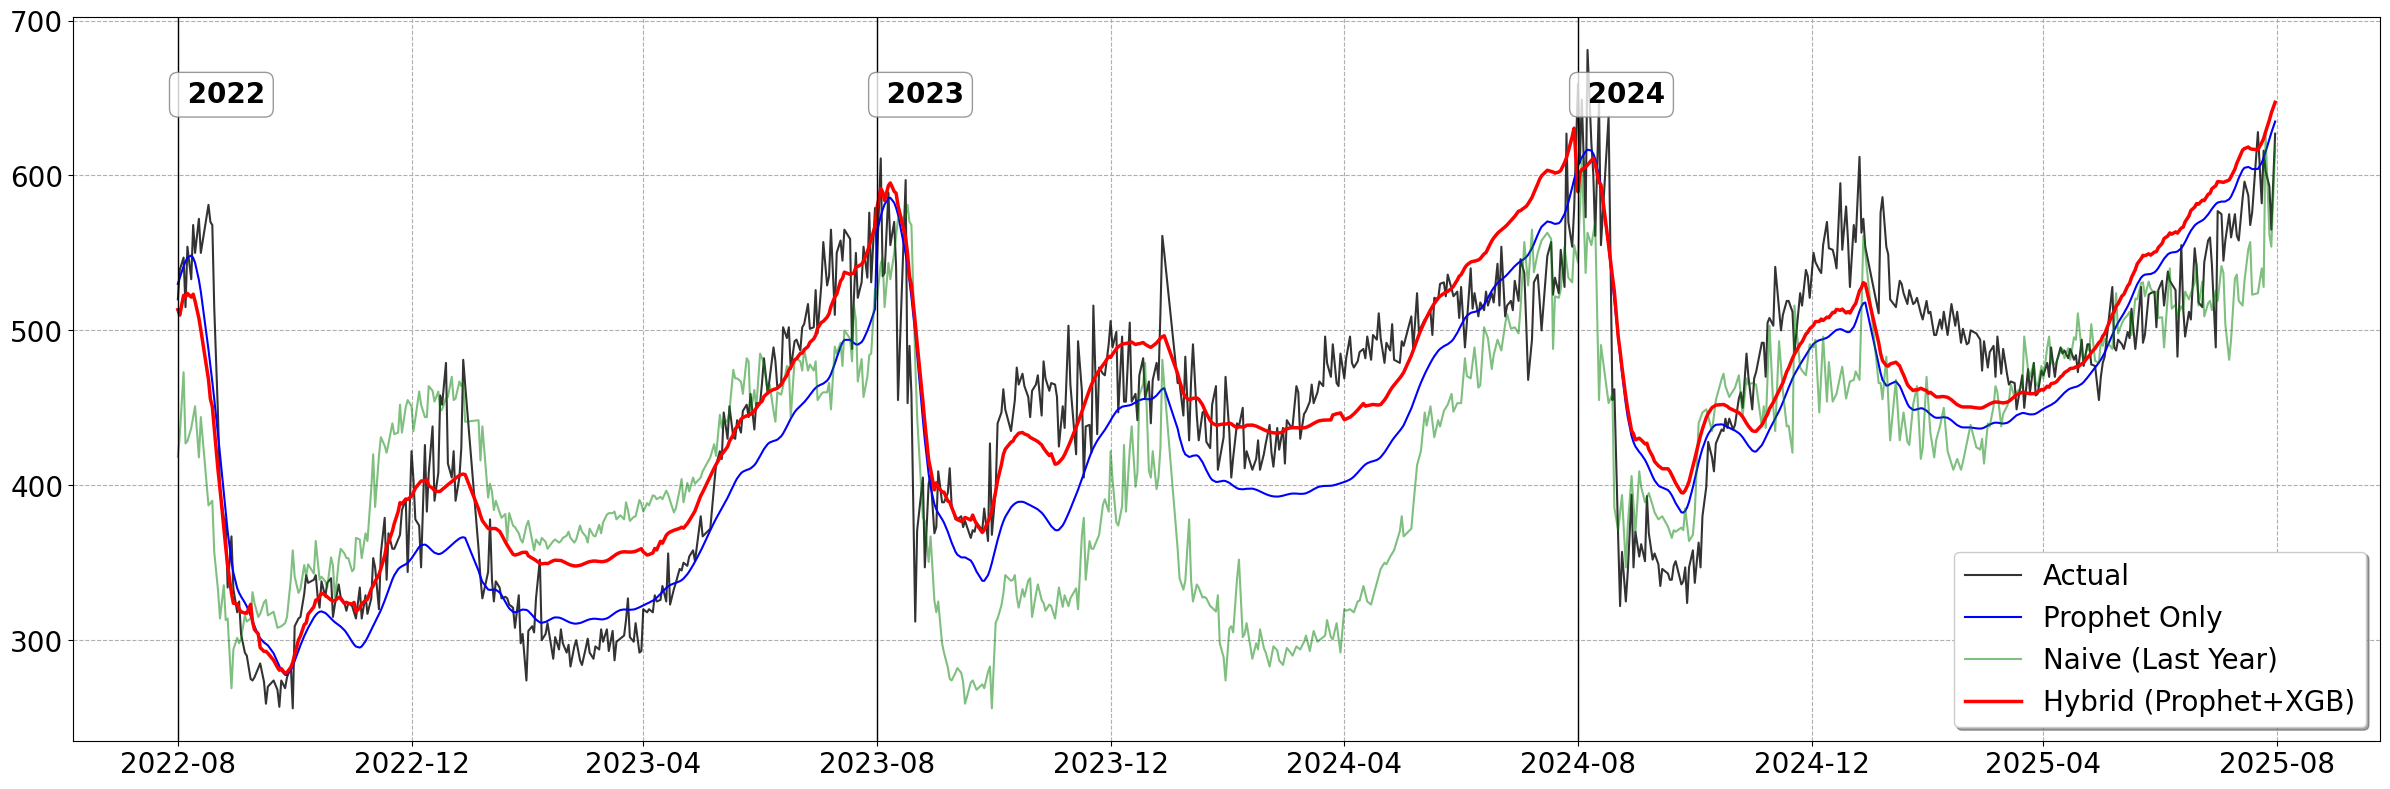

In [9]:
# ==============================================================================
# 4. 比較用データの統合 & グラフ化 (全モデルを同じ濃さではっきり表示)
# ==============================================================================

# --- 1. 前年度参照用マスターの作成 ---
full_date_range = pd.date_range(start=df_master['ds'].min(), end=df_master['ds'].max(), freq='D')
df_lookup = pd.DataFrame({'ds': full_date_range})
df_lookup = df_lookup.merge(df_master[['ds', 'y']], on='ds', how='left')
df_lookup['y_filled'] = df_lookup['y'].interpolate(method='linear')
price_lookup = df_lookup.set_index('ds')['y_filled']

# --- 2. 予測結果の集約 ---
df_all_results = pd.concat(all_results_list).sort_values('ds').reset_index(drop=True)
dates_prev_year = df_all_results['ds'] - pd.DateOffset(years=1)
df_all_results['naive_pred'] = dates_prev_year.map(price_lookup).values

# --- 3. グラフ化 (全モデル alpha=1.0) ---
plt.figure(figsize=(24, 8))

# 実測値: 基準として黒の細線で表示
plt.plot(df_all_results['ds'], df_all_results['y'],
         label='Actual', color='black', alpha=0.8, linewidth=1.5)

# Prophet単体: 深い緑の破線
plt.plot(df_all_results['ds'], df_all_results['prophet_pred'],
         label='Prophet Only', color='blue', alpha=1.0, linewidth=1.5)

# 前年度踏襲: 鮮やかな青の点線
plt.plot(df_all_results['ds'], df_all_results['naive_pred'],
         label='Naive (Last Year)', color='green', alpha=0.5, linewidth=1.5)

# ハイブリッド: 鮮やかな赤の実線
plt.plot(df_all_results['ds'], df_all_results['final_pred'],
         label='Hybrid (Prophet+XGB)', color='red', alpha=1.0, linewidth=2.5)


ax = plt.gca()
# 8, 12, 4月を指定して目盛りを打つ
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[4, 8, 12]))
# 軸の表示形式を 「2022-08」 のような形式にする
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# --- 装飾 ---
for config in VALIDATION_CONFIGS:
    t_start = pd.to_datetime(config['TEST_START'])
    plt.axvline(t_start, color='black', linestyle='-', alpha=1.0, linewidth=1)
    y_max = df_all_results['y'].max()
    plt.text(t_start, y_max * 0.95, f" {config['label']}",
             fontsize=20, fontweight='bold', color='black',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.3'))

# 凡例・グリッド
plt.legend(fontsize=20, loc='lower right', frameon=True, shadow=True)
plt.grid(True, which='both', linestyle='--', alpha=1.0)
plt.tick_params(axis='both', labelsize=20)

plt.tight_layout()
plt.show()

# 図5.1：残差分布のヒストグラム比較

## Prophet単体の残差分布


■ 検証開始: 2022年度
   学習期間: 2014-08-01 ～ 2022-07-31
-> 結果: MAE=28.93, RMSE=37.20, MAPE=7.13%, RMSPE=8.56%

■ 検証開始: 2023年度
   学習期間: 2015-08-01 ～ 2023-07-31
-> 結果: MAE=43.24, RMSE=52.06, MAPE=9.29%, RMSPE=11.45%

■ 検証開始: 2024年度
   学習期間: 2016-08-01 ～ 2024-07-31
-> 結果: MAE=41.88, RMSE=49.53, MAPE=8.86%, RMSPE=10.99%

■ 3年間の検証結果まとめ (多角評価)
  Year   MAE  RMSE  MAPE (%)  RMSPE (%)
2022年度 28.93 37.20      7.13       8.56
2023年度 43.24 52.06      9.29      11.45
2024年度 41.88 49.53      8.86      10.99
------------------------------------------------------------
★ 3期間平均 | MAE: 38.02 | RMSE: 46.27 | MAPE: 8.43% | RMSPE: 10.33%


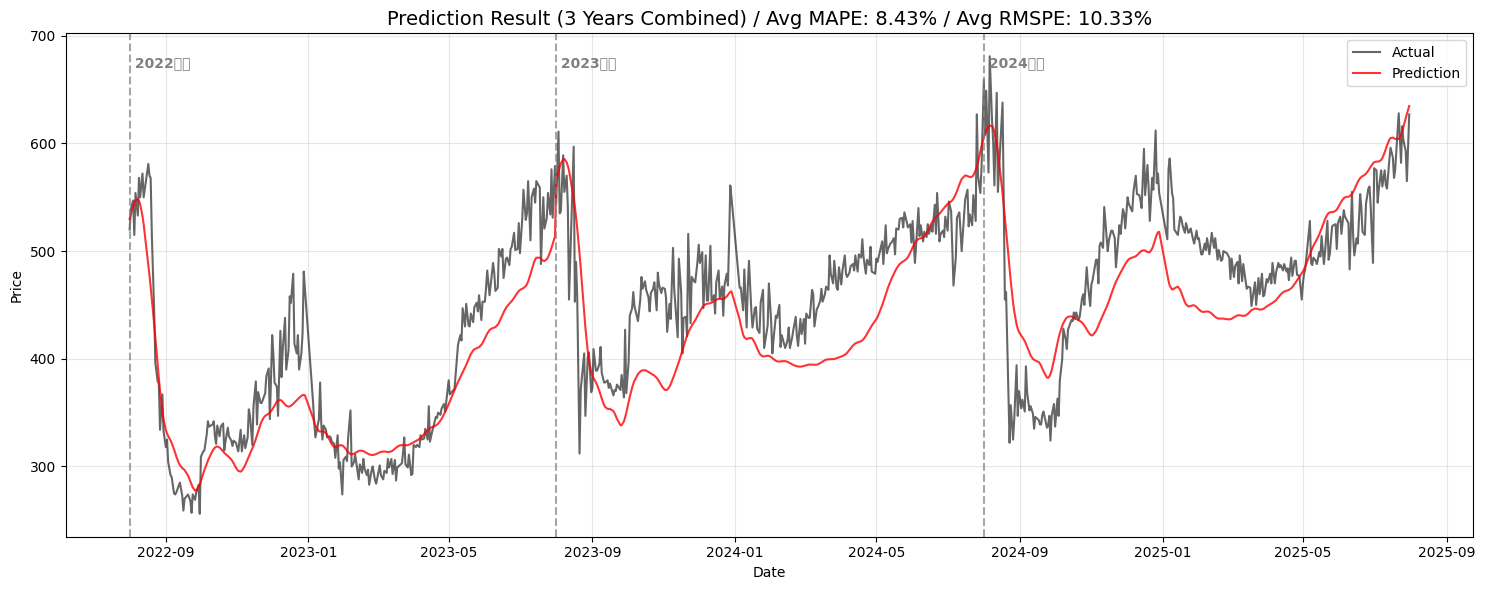

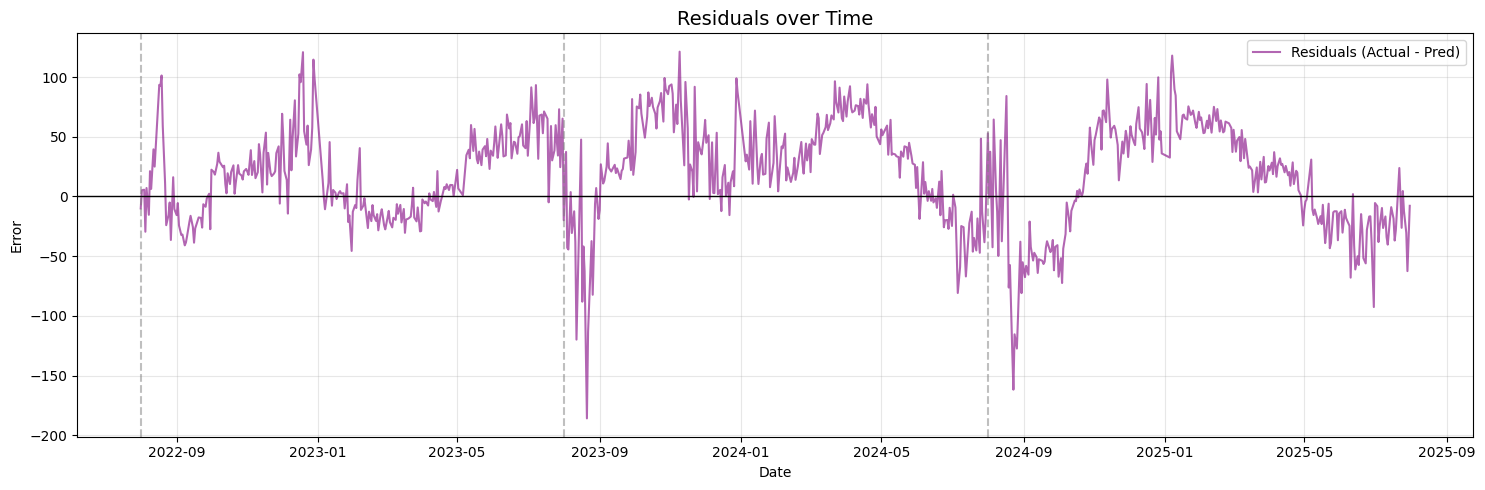

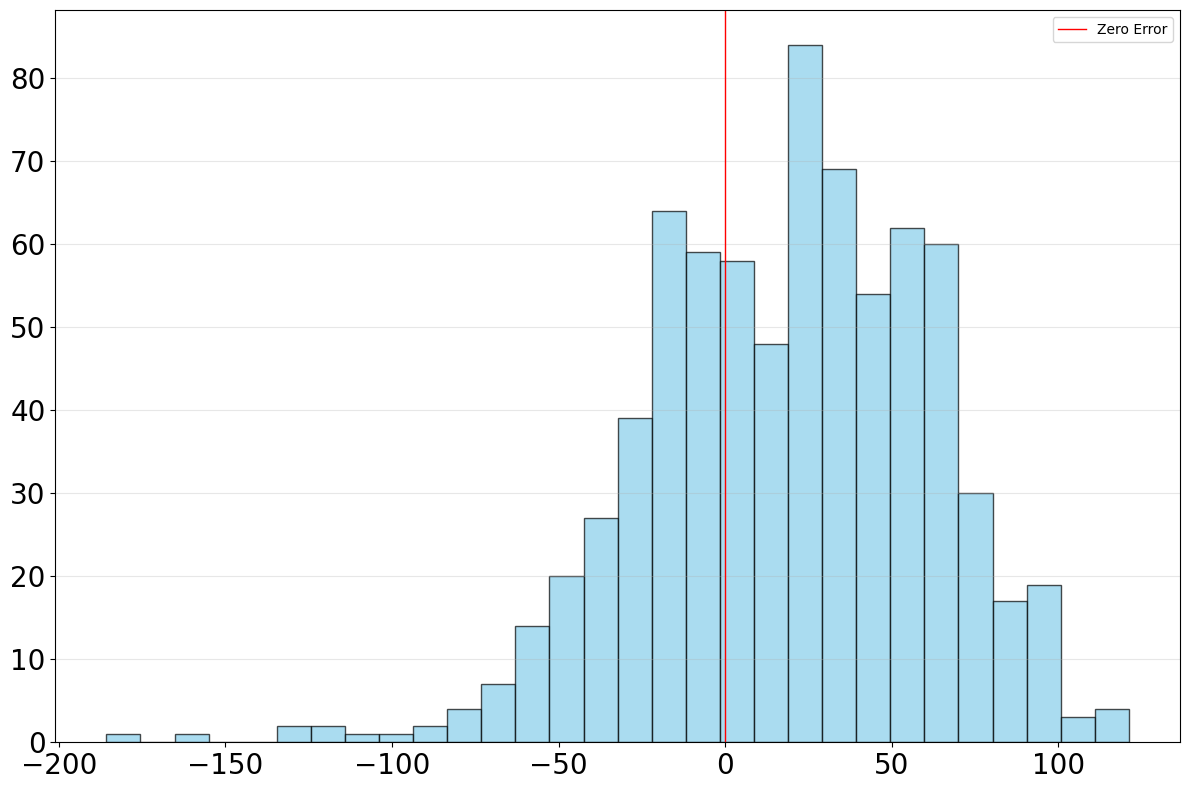

In [12]:
# ==============================================================================
# 1. データ読み込み & 前処理
# ==============================================================================
file_path = '/content/drive/MyDrive/Colab Notebooks/卒業研究/データ/価格、数量.csv'

# データ読み込み
data = pd.read_csv(file_path)

# 価格が0より大きいデータのみ抽出し、日付型に変換
data_filtered = data[data['価格'] > 0].copy()
data_filtered['日付'] = pd.to_datetime(data_filtered['日付'])

# Prophet用にリネームし、日付順にソート
df_master = data_filtered.rename(columns={'日付': 'ds', '価格': 'y'}).sort_values('ds').reset_index(drop=True)

# 検証設定 (Rolling Window)
VALIDATION_CONFIGS = [
    {
        'label': '2022年度',
        'TRAIN_START': '2014-08-01',
        'TRAIN_END':   '2022-07-31',
        'TEST_START':  '2022-08-01',
        'TEST_END':    '2023-07-31'
    },
    {
        'label': '2023年度',
        'TRAIN_START': '2015-08-01',
        'TRAIN_END':   '2023-07-31',
        'TEST_START':  '2023-08-01',
        'TEST_END':    '2024-07-31'
    },
    {
        'label': '2024年度',
        'TRAIN_START': '2016-08-01',
        'TRAIN_END':   '2024-07-31',
        'TEST_START':  '2024-08-01',
        'TEST_END':    '2025-07-31'
    }
]

# 結果格納用
results_metrics = []
all_predictions = pd.DataFrame()

# ==============================================================================
# 2. ループ処理 (年度ごとに学習・予測・評価)
# ==============================================================================
for config in VALIDATION_CONFIGS:
    print(f"\n{'='*60}")
    print(f"■ 検証開始: {config['label']}")
    print(f"   学習期間: {config['TRAIN_START']} ～ {config['TRAIN_END']}")

    # --- データの切り出し ---
    # 学習期間 + テスト期間の全データを抽出
    mask_period = (df_master['ds'] >= config['TRAIN_START']) & (df_master['ds'] <= config['TEST_END'])
    df_period = df_master[mask_period].copy().reset_index(drop=True)

    # 学習データ (Train)
    mask_train = (df_period['ds'] <= config['TRAIN_END'])
    df_train = df_period[mask_train].copy()

    # テストデータ (Test)
    mask_test = (df_period['ds'] >= config['TEST_START']) & (df_period['ds'] <= config['TEST_END'])

    # --- Prophet学習 (指定されたパラメータ) ---
    m = Prophet(
        growth='linear',
        n_changepoints=27,
        seasonality_mode='additive',
        yearly_seasonality=28,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_range=0.6756135296493135,
        seasonality_prior_scale=0.03063549790478998,
        changepoint_prior_scale=0.09679027817732291
    )

    m.fit(df_train[['ds', 'y']])

    # --- 予測 ---
    forecast = m.predict(df_period[['ds']])

    # テスト期間のデータを抽出
    final_pred = forecast.loc[mask_test, 'yhat'].values
    actual = df_period.loc[mask_test, 'y'].values
    dates = df_period.loc[mask_test, 'ds'].values

    # --- 評価指標の計算 (MAE, RMSE, MAPE, RMSPE) ---
    mae = mean_absolute_error(actual, final_pred)
    rmse = np.sqrt(mean_squared_error(actual, final_pred))
    mape = mean_absolute_percentage_error(actual, final_pred) * 100
    rmspe = np.sqrt(np.mean(np.square((actual - final_pred) / actual))) * 100

    # 結果リストに追加
    results_metrics.append({
        'Year': config['label'],
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape,
        'RMSPE (%)': rmspe  # 追加
    })

    print(f"-> 結果: MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.2f}%, RMSPE={rmspe:.2f}%")

    # --- グラフ用データの蓄積 ---
    temp_df = pd.DataFrame({
        'ds': dates,
        'y': actual,
        'yhat': final_pred,
        'label': config['label']
    })
    all_predictions = pd.concat([all_predictions, temp_df], axis=0)

# ==============================================================================
# 3. 最終結果の集計と表示
# ==============================================================================
results_df = pd.DataFrame(results_metrics)

print(f"\n{'='*60}")
print("■ 3年間の検証結果まとめ (多角評価)")
print(f"{'='*60}")
print(results_df.to_string(index=False))

print(f"{'-'*60}")
# 平均値の計算
avg_mae = results_df['MAE'].mean()
avg_rmse = results_df['RMSE'].mean()
avg_mape = results_df['MAPE (%)'].mean()
avg_rmspe = results_df['RMSPE (%)'].mean() # 追加

print(f"★ 3期間平均 | MAE: {avg_mae:.2f} | RMSE: {avg_rmse:.2f} | MAPE: {avg_mape:.2f}% | RMSPE: {avg_rmspe:.2f}%")
print(f"{'='*60}")

# ==============================================================================
# 4. グラフ化 (3年分を結合して表示)
# ==============================================================================
# 日付順に整列
all_predictions = all_predictions.sort_values('ds').reset_index(drop=True)

# 1. 実測値 vs 予測値 (時系列)
plt.figure(figsize=(15, 6))
plt.plot(all_predictions['ds'], all_predictions['y'], label='Actual', color='black', alpha=0.6, linewidth=1.5)
plt.plot(all_predictions['ds'], all_predictions['yhat'], label='Prediction', color='red', alpha=0.8, linewidth=1.5)

# 年度の区切り線を描画
for config in VALIDATION_CONFIGS:
    plt.axvline(pd.to_datetime(config['TEST_START']), color='gray', linestyle='--', alpha=0.7)
    # 年度のラベルをグラフ上部に表示
    plt.text(pd.to_datetime(config['TEST_START']), all_predictions['y'].max(), f" {config['label']}",
             verticalalignment='top', fontsize=10, color='gray', fontweight='bold')

# タイトルにRMSPEも表示
plt.title(f"Prediction Result (3 Years Combined) / Avg MAPE: {avg_mape:.2f}% / Avg RMSPE: {avg_rmspe:.2f}%", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 残差の計算
residuals = all_predictions['y'] - all_predictions['yhat']

# 2. 残差の時系列推移
plt.figure(figsize=(15, 5))
plt.plot(all_predictions['ds'], residuals, color='purple', alpha=0.6, label='Residuals (Actual - Pred)')
plt.axhline(y=0, color='black', linewidth=1)

# 年度の区切り線
for config in VALIDATION_CONFIGS:
    plt.axvline(pd.to_datetime(config['TEST_START']), color='gray', linestyle='--', alpha=0.5)

plt.title("Residuals over Time", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. 残差のヒストグラム (分布確認)
plt.figure(figsize=(12, 8))
plt.hist(residuals, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='-', linewidth=1.0, label='Zero Error')
plt.tick_params(axis='both', labelsize=20)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## ハイブリッドモデルの残差分布（図5.2）


■ 検証開始: 2022年度
1. Prophet学習中...
2. XGBoost学習中...
3. 予測実行中 (再帰的処理)...
-> 2022年度 MAE: 27.54 | RMSE=35.05, | MAPE=7.77%, | RMSPE=10.09%

■ 検証開始: 2023年度
1. Prophet学習中...
2. XGBoost学習中...
3. 予測実行中 (再帰的処理)...
-> 2023年度 MAE: 29.40 | RMSE=38.73, | MAPE=6.26%, | RMSPE=8.70%

■ 検証開始: 2024年度
1. Prophet学習中...
2. XGBoost学習中...
3. 予測実行中 (再帰的処理)...
-> 2024年度 MAE: 40.74 | RMSE=48.07, | MAPE=8.75%, | RMSPE=11.09%

■ 3年間のハイブリッドモデル検証結果まとめ
★ 平均 MAE   : 32.55
★ 平均 RMSE  : 40.97
★ 平均 MAPE  : 7.59%
★ 平均 RMSPE : 10.01%


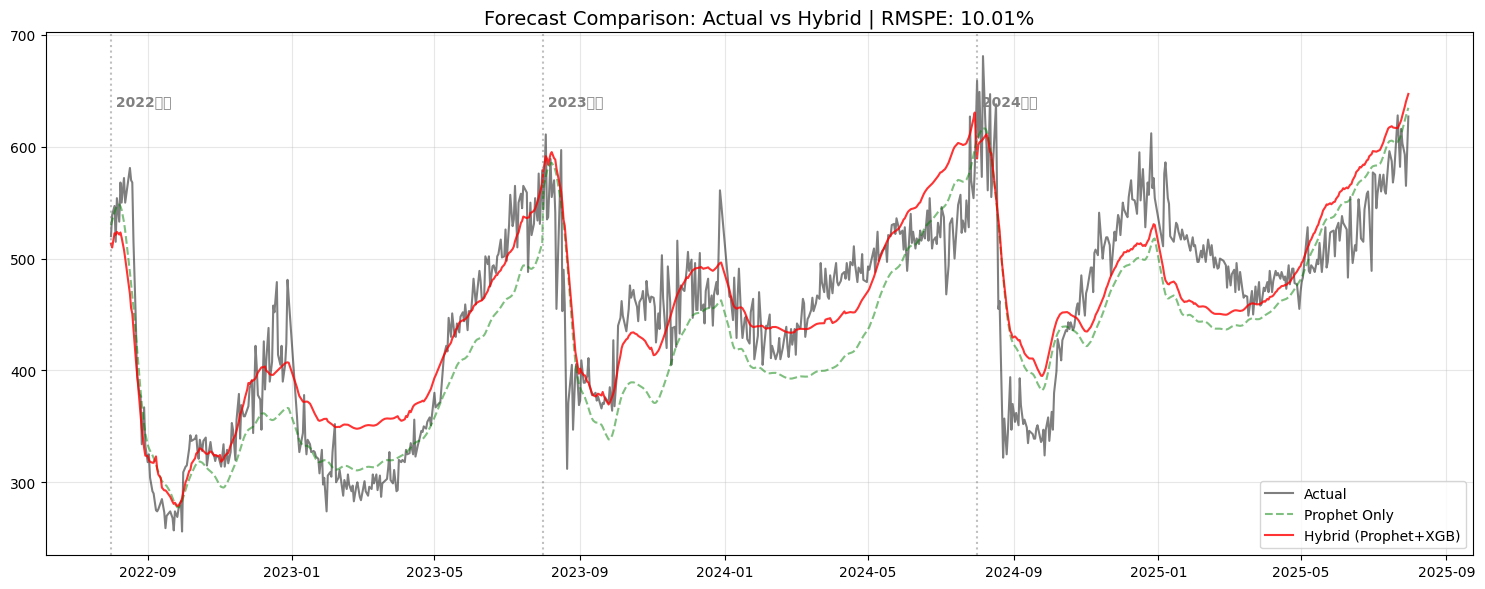

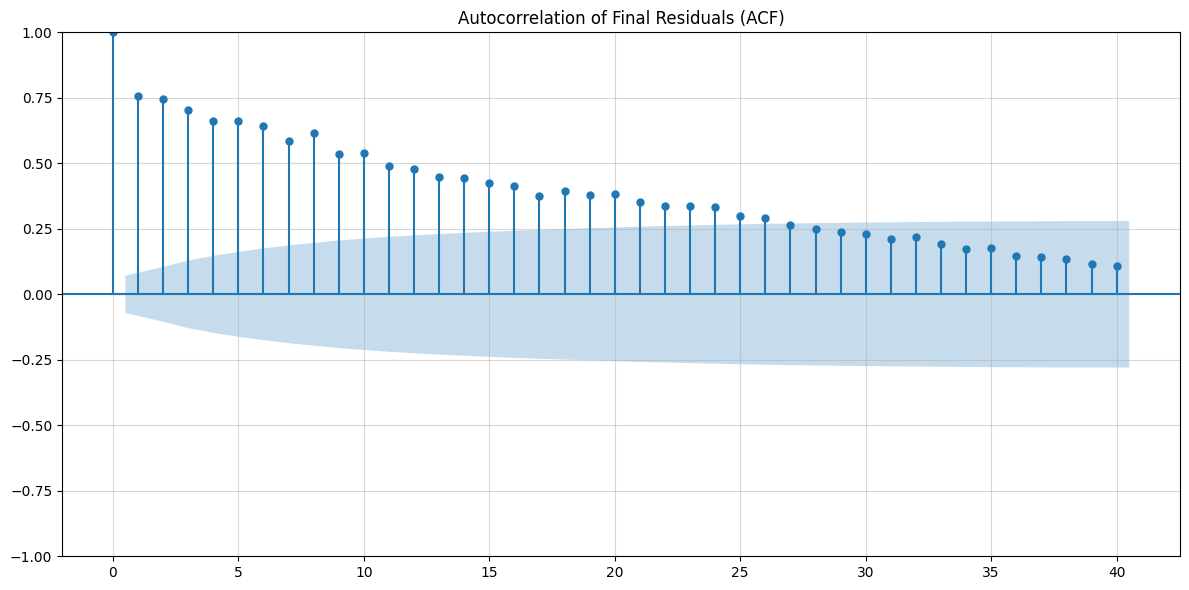

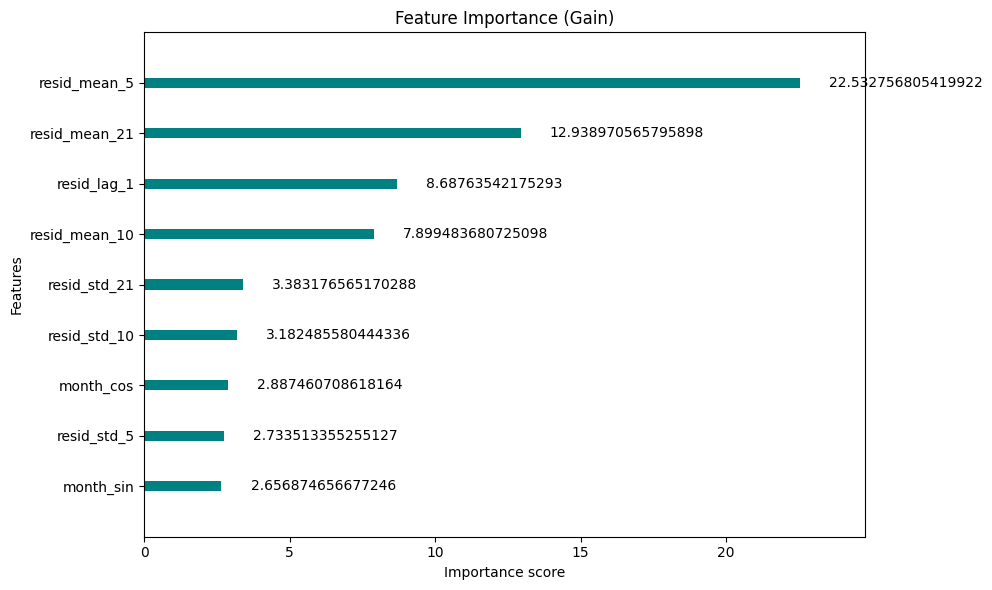

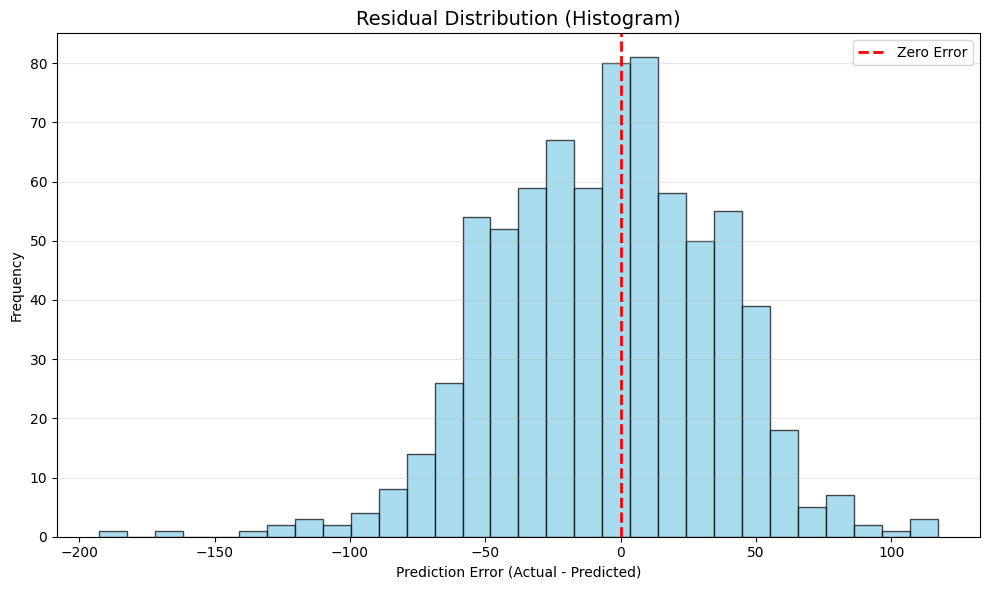

In [11]:
# ==============================================================================
# 1. データ読み込み & 前処理
# ==============================================================================
file_path = '/content/drive/MyDrive/Colab Notebooks/卒業研究/データ/価格、数量.csv'

data = pd.read_csv(file_path)
data['日付'] = pd.to_datetime(data['日付'])

# データ整理
data_filtered = data[data['価格'] > 0].copy()
df_master = data_filtered.rename(columns={'日付': 'ds', '価格': 'y'}).sort_values('ds').reset_index(drop=True)

# 検証設定
VALIDATION_CONFIGS = [
    {'label': '2022年度', 'TRAIN_START': '2014-08-01', 'TRAIN_END': '2022-07-31', 'TEST_START': '2022-08-01', 'TEST_END': '2023-07-31'},
    {'label': '2023年度', 'TRAIN_START': '2015-08-01', 'TRAIN_END': '2023-07-31', 'TEST_START': '2023-08-01', 'TEST_END': '2024-07-31'},
    {'label': '2024年度', 'TRAIN_START': '2016-08-01', 'TRAIN_END': '2024-07-31', 'TEST_START': '2024-08-01', 'TEST_END': '2025-07-31'}
]

# ==============================================================================
# 2. パラメータ設定
# ==============================================================================

Prophet_PARAMS = {
        'growth':'linear',
        'n_changepoints':27,
        'seasonality_mode':'additive',
        'yearly_seasonality':28,
        'weekly_seasonality':False,
        'daily_seasonality':False,
        'changepoint_range':0.6756135296493135,
        'seasonality_prior_scale':0.03063549790478998,
        'changepoint_prior_scale':0.09679027817732291,
}

XGB_PARAMS = {
    'objective': 'reg:absoluteerror',
    'eval_metric': 'mae',
    'booster': 'gbtree',
    'verbosity': 0,
    'seed': 42,
    'max_depth': 11,
    'learning_rate': 0.08008064281256923,
    'min_child_weight': 35,
    'alpha': 0.03240853469266926,
    'lambda': 0.03889764943325178,
    'colsample_bytree': 0.25694867854682896,
    'subsample': 0.7673783790335744,
}

GAP = 1  # 予測の余裕日数
LAGS = [1] # ラグ特徴量
WINDOWS = [5, 10, 21] # 移動平均のウィンドウサイズリスト

all_results_list = [] # 結果結合用

# ==============================================================================
# 3. ループ処理 (Prophet + XGBoost)
# ==============================================================================
for config in VALIDATION_CONFIGS:
    print(f"\n{'='*60}")
    print(f"■ 検証開始: {config['label']}")

    # 期間フィルタリング
    mask_period = (df_master['ds'] >= config['TRAIN_START']) & (df_master['ds'] <= config['TEST_END'])
    df_period = df_master[mask_period].copy().reset_index(drop=True)

    # --- 1. Prophet学習 (トレンド・季節性担当) ---
    print("1. Prophet学習中...")

    m = Prophet(**Prophet_PARAMS)

    train_df = df_period[df_period['ds'] <= config['TRAIN_END']]
    m.fit(train_df[['ds', 'y']])

    # 全期間の予測と残差算出
    forecast = m.predict(df_period[['ds']])
    df_period['prophet_pred'] = forecast['yhat']
    df_period['residual'] = df_period['y'] - df_period['prophet_pred']

    # --- 2. 特徴量エンジニアリング (XGBoost用) ---
    # ラグ特徴量
    for lag in LAGS:
        df_period[f'resid_lag_{lag}'] = df_period['residual'].shift(lag)

    # 移動平均・標準偏差 (ループで一括処理)
    for w in WINDOWS:
        shifted = df_period['residual'].shift(GAP)
        df_period[f'resid_mean_{w}'] = shifted.rolling(window=w).mean()
        df_period[f'resid_std_{w}'] = shifted.rolling(window=w).std()

    # 日付特徴量
    df_period['month'] = df_period['ds'].dt.month
    df_period['month_sin'] = np.sin(2 * np.pi * df_period['month'] / 12)
    df_period['month_cos'] = np.cos(2 * np.pi * df_period['month'] / 12)

    # NaN削除
    df_features = df_period.dropna().reset_index(drop=True)

    # データ分割
    valid_start_dt = pd.to_datetime(config['TRAIN_END']) - pd.DateOffset(years=1) + pd.DateOffset(days=1)

    train_mask = df_features['ds'] < valid_start_dt
    valid_mask = (df_features['ds'] >= valid_start_dt) & (df_features['ds'] <= config['TRAIN_END'])
    test_mask = (df_features['ds'] >= config['TEST_START']) & (df_features['ds'] <= config['TEST_END'])
    train_valid_mask = (df_features['ds'] <= config['TRAIN_END'])

    # 特徴量リスト
    features = [c for c in df_features.columns if c.startswith('resid_') or c in ['month_sin', 'month_cos']]

    # --- 3. XGBoost学習 ---
    print("2. XGBoost学習中...")
    dtrain = xgb.DMatrix(df_features.loc[train_mask, features], label=df_features.loc[train_mask, 'residual'])
    dvalid = xgb.DMatrix(df_features.loc[valid_mask, features], label=df_features.loc[valid_mask, 'residual'])

    # Early Stopping用
    model = xgb.train(
        XGB_PARAMS, dtrain, num_boost_round=3000,
        evals=[(dtrain, 'train'), (dvalid, 'valid')],
        early_stopping_rounds=50, verbose_eval=False
    )

    # 本番用再学習 (Train+Valid)
    dtrain_all = xgb.DMatrix(df_features.loc[train_valid_mask, features], label=df_features.loc[train_valid_mask, 'residual'])
    final_model = xgb.train(XGB_PARAMS, dtrain_all, num_boost_round=model.best_iteration + 1)

    # --- 4. 再帰的予測 (Recursive Forecasting) ---
    print("3. 予測実行中 (再帰的処理)...")

    df_recursive = df_features.copy()
    test_indices = df_features[test_mask].index
    resid_idx = df_recursive.columns.get_loc('residual')
    final_residuals = []

    for i in test_indices:
        # A. 特徴量の更新 (ラグ)
        for lag in LAGS:
            df_recursive.loc[i, f'resid_lag_{lag}'] = df_recursive.iloc[i - lag, resid_idx]

        # B. 移動平均特徴量の更新 (ループで処理して記述漏れを防ぐ)
        # GAP=1 の場合、i-1日目までのデータが確定している
        end_idx = i - GAP

        for w in WINDOWS:
            # ウィンドウの開始位置計算
            start_idx = end_idx - w + 1

            # 直近データのスライス取得
            recent_slice = df_recursive.iloc[start_idx : end_idx + 1, resid_idx]

            # 計算して代入
            df_recursive.loc[i, f'resid_mean_{w}'] = recent_slice.mean()
            df_recursive.loc[i, f'resid_std_{w}'] = recent_slice.std()

        # C. 1日分の予測実行
        dtest_row = xgb.DMatrix(df_recursive.loc[[i], features])
        pred_resid = final_model.predict(dtest_row)[0]

        # D. 残差更新 (次のループのために重要)
        df_recursive.iloc[i, resid_idx] = pred_resid
        final_residuals.append(pred_resid)

    # 最終予測値
    prophet_pred_test = df_features.loc[test_mask, 'prophet_pred'].values
    final_pred = np.maximum(prophet_pred_test + final_residuals, 0)
    actual = df_features.loc[test_mask, 'y'].values

    # 精度計算
    mae = mean_absolute_error(actual, final_pred)
    rmse = np.sqrt(mean_squared_error(actual, final_pred))
    mape = mean_absolute_percentage_error(actual, final_pred) * 100
    rmspe = np.sqrt(np.mean(np.square((actual - final_pred) / actual))) * 100
    print(f"-> {config['label']} MAE: {mae:.2f} | RMSE={rmse:.2f}, | MAPE={mape:.2f}%, | RMSPE={rmspe:.2f}%")

    # 結果保存
    temp_df = pd.DataFrame({
        'ds': df_features.loc[test_mask, 'ds'].values,
        'y': actual,
        'prophet_pred': prophet_pred_test,
        'final_pred': final_pred,
        'label': config['label']
    })
    all_results_list.append(temp_df)

# ==============================================================================
# 4. グラフ化 & 評価
# ==============================================================================
df_all_results = pd.concat(all_results_list).sort_values('ds').reset_index(drop=True)

# 評価指標 (全体)
avg_mae = mean_absolute_error(df_all_results['y'], df_all_results['final_pred'])
avg_rmse = np.sqrt(mean_squared_error(df_all_results['y'], df_all_results['final_pred']))
avg_mape = mean_absolute_percentage_error(df_all_results['y'], df_all_results['final_pred']) * 100
avg_rmspe = np.sqrt(np.mean(((df_all_results['y'] - df_all_results['final_pred']) / df_all_results['y']) ** 2)) * 100

print(f"\n{'='*60}")
print("■ 3年間のハイブリッドモデル検証結果まとめ")
print(f"{'='*60}")
print(f"★ 平均 MAE   : {avg_mae:.2f}")
print(f"★ 平均 RMSE  : {avg_rmse:.2f}")
print(f"★ 平均 MAPE  : {avg_mape:.2f}%")
print(f"★ 平均 RMSPE : {avg_rmspe:.2f}%")
print(f"{'='*60}")

# --- 1. 実測値 vs 予測値 ---
plt.figure(figsize=(15, 6))
plt.plot(df_all_results['ds'], df_all_results['y'], label='Actual', color='black', alpha=0.5)
plt.plot(df_all_results['ds'], df_all_results['prophet_pred'], label='Prophet Only', color='green', alpha=0.5, linestyle='--')
plt.plot(df_all_results['ds'], df_all_results['final_pred'], label='Hybrid (Prophet+XGB)', color='red', alpha=0.8, linewidth=1.5)

for config in VALIDATION_CONFIGS:
    plt.axvline(pd.to_datetime(config['TEST_START']), color='gray', linestyle=':', alpha=0.5)
    y_pos = df_all_results['y'].max() * 0.95
    plt.text(pd.to_datetime(config['TEST_START']), y_pos, f" {config['label']}",
             verticalalignment='top', fontsize=10, color='gray', fontweight='bold')

plt.title(f"Forecast Comparison: Actual vs Hybrid | RMSPE: {avg_rmspe:.2f}%", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 2. 残差の分析 (ACF) ---
residuals_final = df_all_results['y'] - df_all_results['final_pred']
plt.figure(figsize=(12, 6))
plot_acf(residuals_final, lags=40, ax=plt.gca(), title='Autocorrelation of Final Residuals (ACF)', alpha=0.05)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

# --- 3. 特徴量重要度 ---
plt.figure(figsize=(10, 6))
xgb.plot_importance(final_model, max_num_features=15, importance_type='gain',
                    title='Feature Importance (Gain)', grid=False, ax=plt.gca(), color='teal')
plt.tight_layout()
plt.show()

# --- 4. 残差のヒストグラム (追加) ---
plt.figure(figsize=(10, 6))
plt.hist(residuals_final, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.title("Residual Distribution (Histogram)", fontsize=14)
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()